# Import tools

In [1]:
import nmtk
import physio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# Set folder of a patient

In [2]:
folder = "/crnldata/REA_NEURO_MULTI_ICU/raw_data/MF12/"
folder = Path(folder)

# ECG

In [3]:
raw_ecg, srate = nmtk.load_with_pycns(folder = folder,  stream_name='ECG_II', index_selection_slice=slice(0, 50000))

    peak_index  peak_time
0          164   0.328164
1          696   1.392696
2         1265   2.531265
3         1822   3.645822
4         2378   4.758378
..         ...        ...
85       47314  94.675314
86       47869  95.785869
87       48423  96.894423
88       48965  97.978965
89       49548  99.145548

[90 rows x 2 columns]


Text(0.5, 0, 'Time (s)')

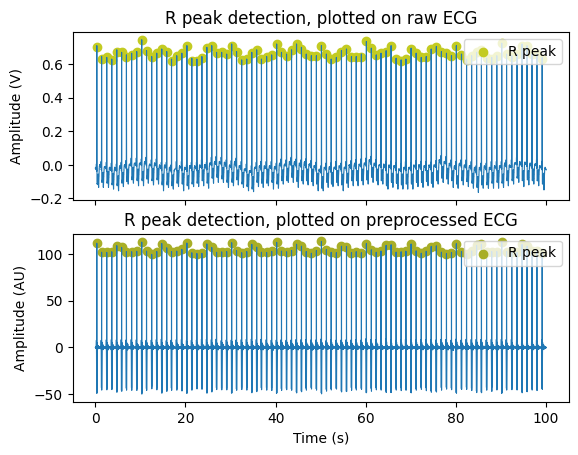

In [4]:
times = np.arange(raw_ecg.size) / srate # build time vector

ecg, ecg_peaks = physio.compute_ecg(raw_ecg, srate, parameter_preset='human_ecg') # set 'human_ecg' as preset because example ecg is from human

# ecg_peaks is a dataframe containing 2 columns : 1) the indices of detection and 2) the times in seconds of detections of the R peaks
print(ecg_peaks)

r_peak_ind = ecg_peaks['peak_index'].values # get index of detected R peaks

linewidth = 0.8
fig, axs = plt.subplots(nrows=2, sharex=True)
ax = axs[0]
ax.plot(times, raw_ecg, lw = linewidth)
ax.scatter(times[r_peak_ind], raw_ecg[r_peak_ind], color="#C3CB22", label = 'R peak')
ax.set_ylabel('Amplitude (V)')
ax.set_title('R peak detection, plotted on raw ECG')
ax.legend(loc = 'upper right')

ax = axs[1]
ax.plot(times, ecg, lw = linewidth)
ax.scatter(times[r_peak_ind], ecg[r_peak_ind], color='#A8AE27', label = 'R peak')
ax.set_ylabel('Amplitude (AU)')
ax.set_title('R peak detection, plotted on preprocessed ECG')
ax.legend(loc = 'upper right')

ax.set_xlabel('Time (s)')

# Respi with CO2

In [5]:
raw_resp, srate = nmtk.load_with_pycns(folder = folder,  stream_name='CO2', index_selection_slice=slice(0, 10000))

    inspi_index  expi_index  next_inspi_index  inspi_time  expi_time  \
0           508         702              1136    4.065524   5.618106   
1          1136        1343              1770    9.091408  10.748029   
2          1770        1969              2395   14.165310  15.757907   
3          2395        2696              3120   19.167185  21.576088   
4          3120        3324              3742   24.969360  26.601972   
5          3742        3958              4374   29.947226  31.675874   
6          4374        4580              5002   35.005122  36.653740   
7          5002        5210              5632   40.031006  41.695630   
8          5632        5843              6268   45.072896  46.761529   
9          6268        6475              6890   50.162804  51.819425   
10         6890        7097              7515   55.140670  56.797291   
11         7515        7716              8143   60.142545  61.751148   
12         8143        8350              8786   65.168429  66.82

Text(0.5, 1.0, 'Respiratory cycle detection')

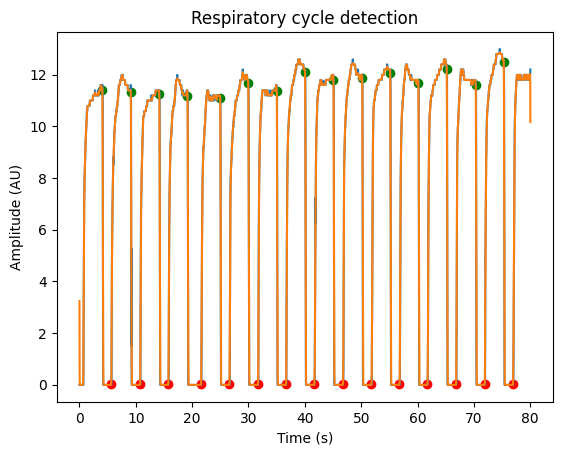

In [6]:
times = np.arange(raw_resp.size) / srate # build time vector

# the easiest way is to use predefined parameters
resp, resp_cycles = physio.compute_respiration(raw_resp, srate, parameter_preset='human_co2') 

# resp_cycles is a dataframe containing all cycles and related features (duration, amplitude, volume, timing, etc...).
print(resp_cycles)

inspi_ind = resp_cycles['inspi_index'].values # get index of inspiration start points
expi_ind = resp_cycles['expi_index'].values # get index of expiration start points

fig, ax = plt.subplots()
ax.plot(times, raw_resp)
ax.plot(times, resp)
ax.scatter(times[inspi_ind], resp[inspi_ind], color='green', label = 'inspiration start')
ax.scatter(times[expi_ind], resp[expi_ind], color='red', label = 'expiration start')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (AU)')
ax.set_title('Respiratory cycle detection')

# Arterial Blood Pressure pulses

In [7]:
raw_abp, srate = nmtk.load_with_pycns(folder = folder,  stream_name='ABP', index_selection_slice=slice(0, 10000))

    trough_ind  trough_time  next_trough_ind  next_trough_time  peak_ind  \
0           55     0.440165              188          1.504564        71   
1          188     1.504564              330          2.640990       204   
2          330     2.640990              470          3.761410       347   
3          470     3.761410              608          4.865824       486   
4          608     4.865824              743          5.946229       624   
..         ...          ...              ...               ...       ...   
65        9050    72.427150             9187         73.523561      9065   
66        9187    73.523561             9325         74.627975      9203   
67        9325    74.627975             9464         75.740392      9341   
68        9464    75.740392             9609         76.900827      9484   
69        9609    76.900827             9748         78.013244      9625   

    peak_time  rise_duration  decay_duration  total_duration  \
0    0.568213       0.1

Text(0.5, 1.0, 'ABP Pulse detection')

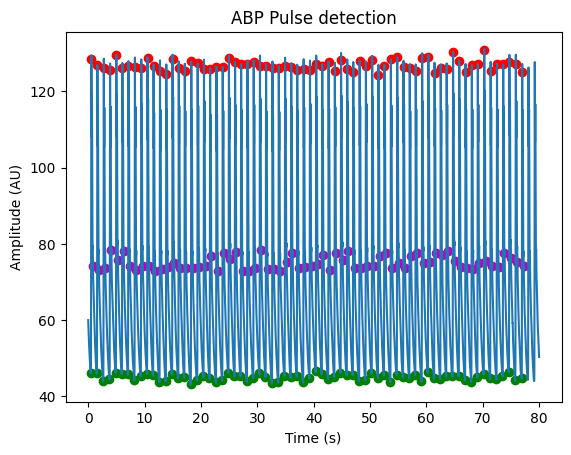

In [8]:
abp_pulses = nmtk.compute_abp(raw_abp, srate)

times = np.arange(raw_abp.size) / srate # build time vector

print(abp_pulses)

trough_inds = abp_pulses['trough_ind'].values 
peak_inds = abp_pulses['peak_ind'].values 
dicrotic_inds = abp_pulses['dicrotic_notch_ind'].values 

fig, ax = plt.subplots()
ax.plot(times, raw_abp)
ax.scatter(times[trough_inds], raw_abp[trough_inds], color='green')
ax.scatter(times[peak_inds], raw_abp[peak_inds], color='red')
ax.scatter(times[dicrotic_inds], raw_abp[dicrotic_inds], color='m')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (AU)')
ax.set_title('ABP Pulse detection')

# Intracranial Pressure pulses

In [9]:
raw_icp, srate = nmtk.load_with_pycns(folder = folder,  stream_name='ICP', index_selection_slice=slice(0, 10000))

    trough_ind  trough_time  next_trough_ind  next_trough_time  peak_ind  \
0           53     0.424159              186          1.488558        84   
1          186     1.488558              328          2.624984       221   
2          328     2.624984              468          3.745404       364   
3          468     3.745404              606          4.849818       500   
4          606     4.849818              741          5.930223       640   
..         ...          ...              ...               ...       ...   
69        9306    74.475918             9395         75.188185      9362   
70        9395    75.188185             9469         75.780407      9409   
71        9469    75.780407             9612         76.924836      9494   
72        9612    76.924836             9750         78.029250      9655   
73        9750    78.029250             9846         78.797538      9797   

    peak_time  rise_duration  decay_duration  total_duration  \
0    0.672252       0.2

Text(0.5, 1.0, 'ICP Pulse detection')

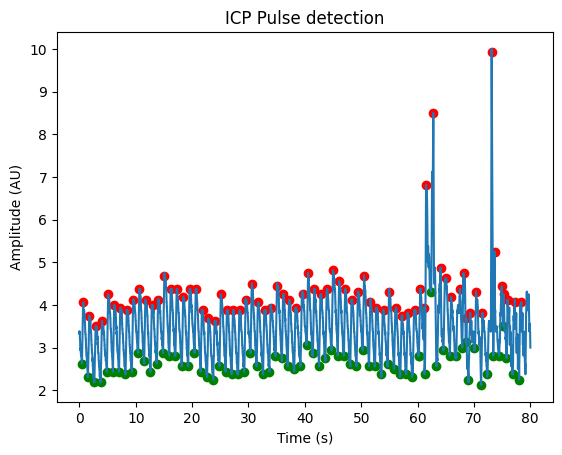

In [10]:
icp_pulses = nmtk.compute_icp(raw_icp, srate)

times = np.arange(raw_icp.size) / srate # build time vector

print(icp_pulses)

trough_inds = icp_pulses['trough_ind'].values 
peak_inds = icp_pulses['peak_ind'].values 

fig, ax = plt.subplots()
ax.plot(times, raw_icp)
ax.scatter(times[trough_inds], raw_icp[trough_inds], color='green')
ax.scatter(times[peak_inds], raw_icp[peak_inds], color='red')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (AU)')
ax.set_title('ICP Pulse detection')